In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
from scipy.ndimage import center_of_mass
import heapq
import random
from tqdm import tqdm
import heapq
from matplotlib.collections import LineCollection


## Importing and/or generating room layouts 

House 24x24 layout 

Cell 1: '24x24' Whole House Floorplan generated.


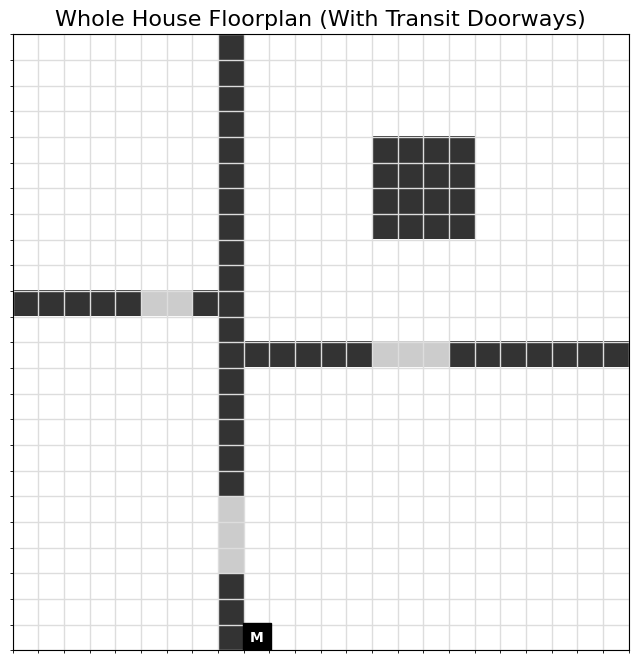

In [2]:
# ==========================================
# CELL 0:  HOUSE PLAN / ENVIRONMENT
# ==========================================


MANIFOLD_POS = (23, 9) # Inside the Top-Left Utility Room

def generate_floorplan(layout_type="house"):
    """Generates environments. 'house' is a 24x24 full floorplan."""
    if layout_type == "house":
        GRID_SIZE = 24
        grid = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.int8)
        
        # 1. Main Interior Walls
        grid[0:24, 8] = -1         
        grid[12, 8:24] = -1        
        grid[10, 0:8] = -1         
        
        # 2. Doorways (Marked as -2: Transit Tiles!)
        grid[10, 5:7] = -2         # Door to Top-Left Utility Room
        grid[12, 14:17] = -2       # Wide double-door to Bottom-Right Room
        grid[18:21, 8] = -2        # Hallway opening to Bottom-Left Room
        
        # 3. Obstacles
        grid[4:8, 14:18] = -1      # Large Kitchen Island in the Living Room
        
        return grid
    else:
        grid = np.zeros((12, 12), dtype=np.int8)
        return grid

# Set up our working environment
room_grid = generate_floorplan("house")
print(f"Cell 1: '{room_grid.shape[0]}x{room_grid.shape[1]}' Whole House Floorplan generated.")

#  Visualization 
fig, ax = plt.subplots(figsize=(8, 8))
vis_rgb = np.ones((room_grid.shape[0], room_grid.shape[1], 3)) 
vis_rgb[room_grid == -1] = [0.2, 0.2, 0.2] # Dark walls
vis_rgb[room_grid == -2] = [0.8, 0.8, 0.8] # Light Gray for Transit Tiles/Doorways

ax.imshow(vis_rgb)
ax.plot(MANIFOLD_POS[1], MANIFOLD_POS[0], 's', color='black', markersize=20)
ax.text(MANIFOLD_POS[1], MANIFOLD_POS[0], 'M', color='white', ha='center', va='center', fontweight='bold')

ax.set_xticks(np.arange(-0.5, room_grid.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, room_grid.shape[0], 1), minor=True)
ax.grid(which="minor", color="#dddddd", linestyle='-', linewidth=1)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Whole House Floorplan (With Transit Doorways)", fontsize=16)
plt.show()

## Sectioning Lay -out into zones


Architect is sectioning the house...


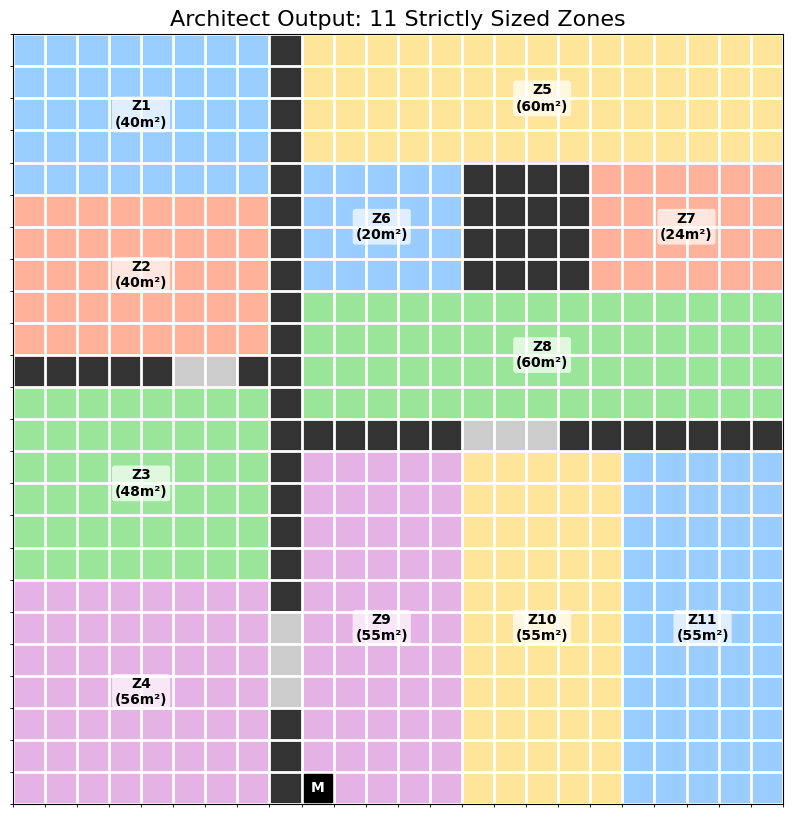

In [3]:
# ==========================================
# CELL 1: THE ARCHITECT (WITH SUB-ZONING)
# ==========================================


MIN_AREA_THRESHOLD = 15       
MAX_AREA_THRESHOLD = 60       
MAX_ABSORPTIONS_PER_ZONE = 1  

# 1. CORE BSP ALGORITHM
def get_bbox(mask):
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    return rmin, rmax, cmin, cmax

def is_perfect_rectangle(mask):
    if not np.any(mask): return False
    rmin, rmax, cmin, cmax = get_bbox(mask)
    return ((rmax - rmin + 1) * (cmax - cmin + 1)) == np.sum(mask)

def split_into_rectangles(mask, memo=None):
    if memo is None: memo = {}
    mask_bytes = mask.tobytes()
    if mask_bytes in memo: return memo[mask_bytes]

    if is_perfect_rectangle(mask): return [mask]

    rmin, rmax, cmin, cmax = get_bbox(mask)
    min_zones, best_splits = float('inf'), None

    for r in range(rmin, rmax):
        top, bot = mask.copy(), mask.copy()
        top[r+1:, :], bot[:r+1, :] = False, False
        if np.any(top) and np.any(bot):
            zones = split_into_rectangles(top, memo) + split_into_rectangles(bot, memo)
            if len(zones) < min_zones: min_zones, best_splits = len(zones), zones

    for c in range(cmin, cmax):
        left, right = mask.copy(), mask.copy()
        left[:, c+1:], right[:, :c+1] = False, False
        if np.any(left) and np.any(right):
            zones = split_into_rectangles(left, memo) + split_into_rectangles(right, memo)
            if len(zones) < min_zones: min_zones, best_splits = len(zones), zones

    memo[mask_bytes] = best_splits
    return best_splits

# 2. OVERSIZED ZONE SUB-DIVIDER (Extension 4)
def split_oversized_zones(zones, max_area):
    final_zones = []
    for mask in zones:
        area = np.sum(mask)
        if area <= max_area:
            final_zones.append(mask)
        else:
            rmin, rmax, cmin, cmax = get_bbox(mask)
            h, w = rmax - rmin + 1, cmax - cmin + 1
            num_splits = int(np.ceil(area / max_area)) # Divide by smallest integer
            
            if w > h: # Cut vertically
                split_size = w // num_splits
                for i in range(num_splits):
                    new_mask = np.zeros_like(mask)
                    start_c = cmin + i * split_size
                    end_c = cmax if i == num_splits - 1 else cmin + (i + 1) * split_size - 1
                    new_mask[rmin:rmax+1, start_c:end_c+1] = mask[rmin:rmax+1, start_c:end_c+1]
                    final_zones.append(new_mask)
            else: # Cut horizontally
                split_size = h // num_splits
                for i in range(num_splits):
                    new_mask = np.zeros_like(mask)
                    start_r = rmin + i * split_size
                    end_r = rmax if i == num_splits - 1 else rmin + (i + 1) * split_size - 1
                    new_mask[start_r:end_r+1, cmin:cmax+1] = mask[start_r:end_r+1, cmin:cmax+1]
                    final_zones.append(new_mask)
    return final_zones

# 3. MERGE FILTER 
def get_neighbors_mask(mask):
    shifted = np.zeros_like(mask)
    shifted[:-1, :] |= mask[1:, :]
    shifted[1:, :] |= mask[:-1, :]
    shifted[:, :-1] |= mask[:, 1:]
    shifted[:, 1:] |= mask[:, :-1]
    return shifted

def optimize_zones(zones, min_area, max_area, max_absorptions):
    tracked_zones = [[z.copy(), 0] for z in zones]
    unmergeable = set()
    
    while True:
        areas = [np.sum(tz[0]) for tz in tracked_zones]
        eligible = [i for i, a in enumerate(areas) if a < min_area and i not in unmergeable]
        
        if not eligible: break
            
        target_idx = min(eligible, key=lambda i: areas[i])
        target_mask, target_area = tracked_zones[target_idx][0], areas[target_idx]
        footprint = get_neighbors_mask(target_mask)
        
        best_neighbor, max_shared = -1, 0
        
        for i, (neighbor_mask, absorb_count) in enumerate(tracked_zones):
            if i == target_idx or absorb_count >= max_absorptions: continue 
            if areas[i] + target_area > max_area: continue
                
            shared = np.sum(footprint & neighbor_mask)
            if shared > max_shared:
                max_shared, best_neighbor = shared, i
            elif shared == max_shared and shared > 0:
                if areas[i] < areas[best_neighbor]: best_neighbor = i
                    
        if best_neighbor != -1:
            tracked_zones[best_neighbor][0] |= target_mask
            tracked_zones[best_neighbor][1] += 1
            tracked_zones.pop(target_idx)
            unmergeable.clear() 
        else:
            unmergeable.add(target_idx)

    return [tz[0] for tz in tracked_zones]

# ==========================================
# EXECUTE & VISUALIZE
# ==========================================
print("Architect is sectioning the house...")

# NOTE: We strictly use == 0. Transit tiles (-2) and Walls (-1) are both completely ignored!
walkable = (room_grid == 0)
initial_zones = split_into_rectangles(walkable)

# Run the new oversized slicer BEFORE we optimize
sliced_zones = split_oversized_zones(initial_zones, MAX_AREA_THRESHOLD)

final_zones = optimize_zones(sliced_zones, MIN_AREA_THRESHOLD, MAX_AREA_THRESHOLD, MAX_ABSORPTIONS_PER_ZONE)

# Render
fig, ax = plt.subplots(figsize=(10, 10))
vis_rgb = np.ones((room_grid.shape[0], room_grid.shape[1], 3)) 
vis_rgb[room_grid == -1] = [0.2, 0.2, 0.2]
vis_rgb[room_grid == -2] = [0.8, 0.8, 0.8] # Doorways remain unzoned!

colors = [[0.6, 0.8, 1.0], [1.0, 0.7, 0.6], [0.6, 0.9, 0.6], [0.9, 0.7, 0.9], [1.0, 0.9, 0.6]]
for i, mask in enumerate(final_zones):
    vis_rgb[mask] = colors[i % len(colors)]
    cy, cx = center_of_mass(mask)
    ax.text(cx, cy, f"Z{i+1}\n({np.sum(mask)}m²)", 
            color='black', fontsize=10, fontweight='bold', ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

ax.imshow(vis_rgb)
ax.plot(MANIFOLD_POS[1], MANIFOLD_POS[0], 's', color='black', markersize=20, zorder=5)
ax.text(MANIFOLD_POS[1], MANIFOLD_POS[0], 'M', color='white', ha='center', va='center', fontweight='bold', zorder=6)

ax.set_xticks(np.arange(-0.5, room_grid.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, room_grid.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linestyle='-', linewidth=2)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"Architect Output: {len(final_zones)} Strictly Sized Zones", fontsize=16)
plt.show()

## Pipe Length Feasibility Check and Rezoning

 PLUMBING MANIFEST 
Physical Pump Limit: 160m per loop

Zone 01 | Area: 40m² | Highway: 21m | Total Pipe: 122m | OK
Zone 02 | Area: 40m² | Highway: 15m | Total Pipe: 110m | OK
Zone 03 | Area: 48m² | Highway: 07m | Total Pipe: 110m | OK
Zone 04 | Area: 56m² | Highway: 05m | Total Pipe: 122m | OK
Zone  | Area: 60m² | Pipe: 178m | FAILED -> Splitting Zone...
Zone 05 | Area: 20m² | Highway: 25m | Total Pipe: 090m | OK
Zone 06 | Area: 24m² | Highway: 30m | Total Pipe: 108m | OK
Zone 07 | Area: 60m² | Highway: 20m | Total Pipe: 160m | OK
Zone 08 | Area: 55m² | Highway: 00m | Total Pipe: 110m | OK
Zone 09 | Area: 55m² | Highway: 04m | Total Pipe: 118m | OK
Zone 10 | Area: 55m² | Highway: 09m | Total Pipe: 128m | OK
Zone 11 | Area: 28m² | Highway: 29m | Total Pipe: 114m | OK
Zone 12 | Area: 32m² | Highway: 34m | Total Pipe: 132m | OK

Cell 3 Complete. Edge-Graph Routes & Constraints Verified.


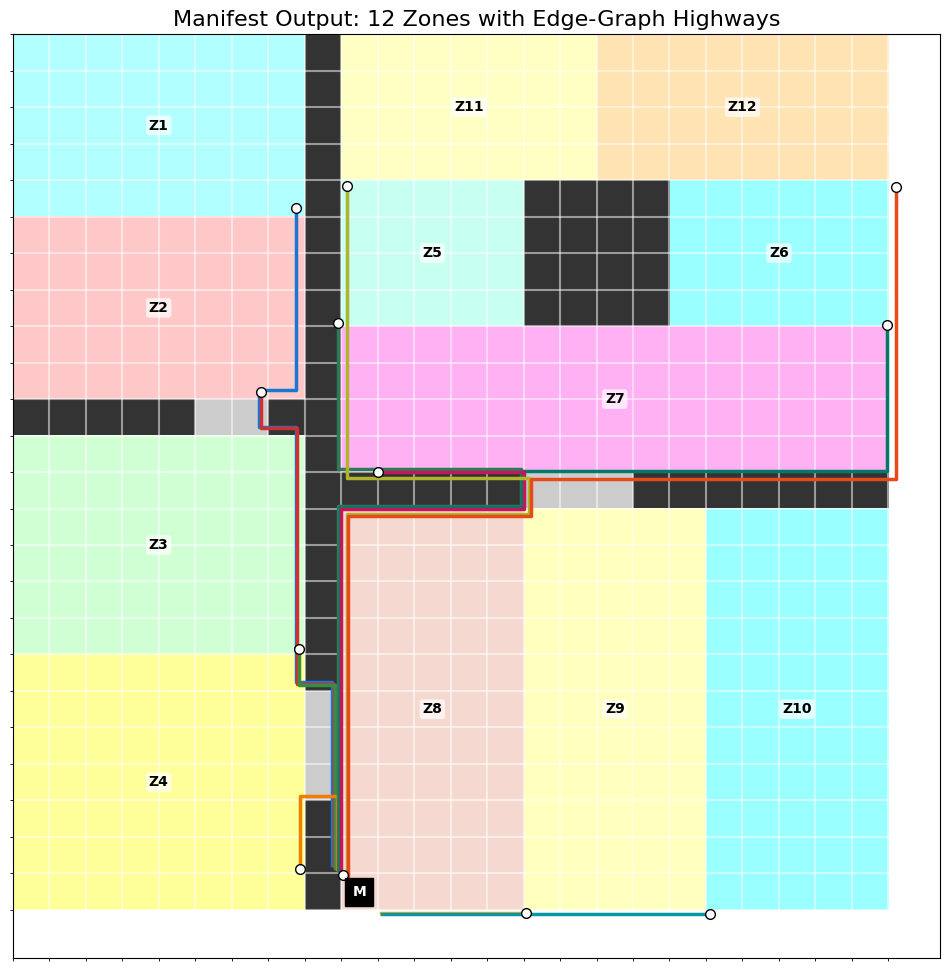

In [ ]:
# ==========================================
# CELL 2: EDGE-GRAPH ROUTER & MANIFEST
# ==========================================


#  ENGINEERING PARAMETERS 
MAX_PHYSICAL_PIPE = 160  # max length is 60-80 m , cell is 0,4 m ->  cells max length 64 m , 160 cell

def find_zone_corners(zone_mask):
    corners = []
    rows, cols = np.where(zone_mask)
    for r, c in zip(rows, cols):
        neighbors = 0
        for dr, dc in [(-1,0), (1,0), (0,-1), (0,1)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < zone_mask.shape[0] and 0 <= nc < zone_mask.shape[1]:
                if zone_mask[nr, nc]:
                    neighbors += 1
        if neighbors <= 2:
            corners.append((r, c))
    return corners

def split_zone_in_half(mask):
    rows, cols = np.any(mask, axis=1), np.any(mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    h, w = rmax - rmin + 1, cmax - cmin + 1
    mask_a, mask_b = np.zeros_like(mask), np.zeros_like(mask)
    if w > h: 
        mid_c = cmin + (w // 2)
        mask_a[rmin:rmax+1, cmin:mid_c] = mask[rmin:rmax+1, cmin:mid_c]
        mask_b[rmin:rmax+1, mid_c:cmax+1] = mask[rmin:rmax+1, mid_c:cmax+1]
    else: 
        mid_r = rmin + (h // 2)
        mask_a[rmin:mid_r, cmin:cmax+1] = mask[rmin:mid_r, cmin:cmax+1]
        mask_b[mid_r:rmax+1, cmin:cmax+1] = mask[mid_r:rmax+1, cmin:cmax+1]
    return [mask_a, mask_b]

#  EDGE-GRAPH DIJKSTRA 
def get_v_edge_cost(vr, vc, grid, z_map):
    if vr >= grid.shape[0]: return 9999
    def get_cell(r, c):
        if r < 0 or r >= grid.shape[0] or c < 0 or c >= grid.shape[1]: return -1
        if grid[r, c] == -1: return -1
        if grid[r, c] == -2: return -2
        return z_map[r, c]
    left, right = get_cell(vr, vc-1), get_cell(vr, vc)
    if left == -1 and right == -1: return 9999 # Inside a wall
    if left == -2 or right == -2: return 1     # Doorway
    if left != right: return 1                 # Zone Seam or Wall Edge
    return 500 # Open floor penalty

def get_h_edge_cost(vr, vc, grid, z_map):
    if vc >= grid.shape[1]: return 9999
    def get_cell(r, c):
        if r < 0 or r >= grid.shape[0] or c < 0 or c >= grid.shape[1]: return -1
        if grid[r, c] == -1: return -1
        if grid[r, c] == -2: return -2
        return z_map[r, c]
    top, bot = get_cell(vr-1, vc), get_cell(vr, vc)
    if top == -1 and bot == -1: return 9999
    if top == -2 or bot == -2: return 1
    if top != bot: return 1
    return 500

def get_vertex_highway(start_cell, end_cell, grid, z_map):
    sr, sc = start_cell
    er, ec = end_cell
    
    start_vertices = [(sr,sc), (sr+1,sc), (sr,sc+1), (sr+1,sc+1)]
    end_vertices = [(er,ec), (er+1,ec), (er,ec+1), (er+1,ec+1)]
        
    queue = []
    for sv in start_vertices: heapq.heappush(queue, (0, sv, [sv]))
    visited = set()
    
    while queue:
        cost, curr, path = heapq.heappop(queue)
        if curr in end_vertices: return path
        if curr in visited: continue
        visited.add(curr)
        
        vr, vc = curr
        if vr > 0:
            cst = get_v_edge_cost(vr-1, vc, grid, z_map)
            if cst < 9000: heapq.heappush(queue, (cost + cst, (vr-1, vc), path + [(vr-1, vc)]))
        if vr < grid.shape[0]:
            cst = get_v_edge_cost(vr, vc, grid, z_map)
            if cst < 9000: heapq.heappush(queue, (cost + cst, (vr+1, vc), path + [(vr+1, vc)]))
        if vc > 0:
            cst = get_h_edge_cost(vr, vc-1, grid, z_map)
            if cst < 9000: heapq.heappush(queue, (cost + cst, (vr, vc-1), path + [(vr, vc-1)]))
        if vc < grid.shape[1]:
            cst = get_h_edge_cost(vr, vc, grid, z_map)
            if cst < 9000: heapq.heappush(queue, (cost + cst, (vr, vc+1), path + [(vr, vc+1)]))
    return []

# ==========================================
# EXECUTE: CALCULATE & FIX MANIFEST
# ==========================================
print(" PLUMBING MANIFEST ")
print(f"Physical Pump Limit: {MAX_PHYSICAL_PIPE}m per loop\n")

engineering_manifest = []
zones_to_process = final_zones.copy()
verified_zones = []
processed_count = 0

while zones_to_process:
    # Build Z-Map dynamically so edge routing knows where current boundaries are
    current_all_zones = verified_zones + zones_to_process
    z_map = np.zeros_like(room_grid, dtype=int)
    for i, z in enumerate(current_all_zones): 
        z_map[z] = i + 1
        
    zone = zones_to_process.pop(0)
    area = np.sum(zone)
    corners = find_zone_corners(zone)
    
    best_corner, best_hw_path = None, []
    min_hw_dist = float('inf')
    
    # Calculate perfect Edge-Routes for Manifest constraints
    for corner in corners:
        path = get_vertex_highway(MANIFOLD_POS, corner, room_grid, z_map)
        if 0 < len(path) < min_hw_dist:
            min_hw_dist = len(path)
            best_hw_path = path
            best_corner = corner
            
    # Distance is number of vertices - 1
    hw_dist = len(best_hw_path) - 1 if best_hw_path else 0
    total_pipe_length = (area * 2) + (hw_dist * 2)
    
    if total_pipe_length > MAX_PHYSICAL_PIPE:
        print(f"Zone  | Area: {area:02d}m² | Pipe: {total_pipe_length:03d}m | FAILED -> Splitting Zone...")
        sub_zones = split_zone_in_half(zone)
        zones_to_process.extend(sub_zones)
    else:
        processed_count += 1
        verified_zones.append(zone)
        engineering_manifest.append({
            'zone_id': processed_count,
            'area': area,
            'mask': zone,
            'start_corner': best_corner,
            'hw_v_path': best_hw_path, # STORE THE VERTEX PATH
            'hw_dist': hw_dist,
            'total_pipe': total_pipe_length
        })
        print(f"Zone {processed_count:02d} | Area: {area:02d}m² | Highway: {hw_dist:02d}m | Total Pipe: {total_pipe_length:03d}m | OK")

print("\nCell 3 Complete. Edge-Graph Routes & Constraints Verified.")


# Visual verification 
import matplotlib.colors as mcolors

#  Quick Verification Render (With Edge-Graph Highways & Start Corners) 
fig, ax = plt.subplots(figsize=(12, 12))
vis_rgb = np.ones((room_grid.shape[0], room_grid.shape[1], 3)) 
vis_rgb[room_grid == -1] = [0.2, 0.2, 0.2]
vis_rgb[room_grid == -2] = [0.8, 0.8, 0.8] 

# Rich, dark CAD color palette (Zero pastels!)
cad_colors = ['#1976D2', '#D32F2F', '#388E3C', '#F57C00', "#2E7A57", 
              '#00796B', '#C2185B', '#5D4037', '#F9A825', '#0097A7', 
              '#AFB42B', '#E64A19', '#303F9F', '#455A64']

# 1. Draw the Faded Zone Backgrounds
for i, data in enumerate(engineering_manifest):
    c_hex = cad_colors[i % len(cad_colors)]
    c_rgb = mcolors.to_rgb(c_hex)
    
    # Lighten the background color heavily so the dark lines pop over them
    vis_rgb[data['mask']] = [min(1.0, c + 0.6) for c in c_rgb] 
    
    cy, cx = center_of_mass(data['mask'])
    ax.text(cx, cy, f"Z{data['zone_id']}", color='black', fontsize=10, fontweight='bold', ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

ax.imshow(vis_rgb)

# 2. Draw the Edge-Graph Highway Routes and Start Corners
for i, data in enumerate(engineering_manifest):
    hw_v_path = data.get('hw_v_path', [])
    c_hex = cad_colors[i % len(cad_colors)]
    
    if hw_v_path:
        offset = (i - len(engineering_manifest)/2) * 0.04
        hx_off = [vc - 0.5 + offset for vr, vc in hw_v_path]
        hy_off = [vr - 0.5 + offset for vr, vc in hw_v_path]
        
        # Plot the dark highway line
        ax.plot(hx_off, hy_off, color=c_hex, linewidth=2.5)
        
        # Mark the chosen Starting Corner 
        end_x, end_y = hx_off[-1], hy_off[-1]
        ax.plot(end_x, end_y, marker='o', color='white', markeredgecolor='black', markersize=7, zorder=5)

# Mark the Manifold 
ax.plot(MANIFOLD_POS[1], MANIFOLD_POS[0], 's', color='black', markersize=20, zorder=10)
ax.text(MANIFOLD_POS[1], MANIFOLD_POS[0], 'M', color='white', ha='center', va='center', fontweight='bold', zorder=11)

ax.set_xticks(np.arange(-0.5, room_grid.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, room_grid.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linestyle='-', linewidth=1.5, alpha=0.5)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"Manifest Output: {len(engineering_manifest)} Zones with Edge-Graph Highways", fontsize=16)
plt.show()

# Zone Piping Layout: Evolutionairy Algorithm

## Highway modeled WITHOUT heating distribution -> edge routing (dijkstra)

Plumber is routing pipes inside verified zones...


Zoned Evolution:   0%|          | 0/12 [00:00<?, ?it/s]

Zoned Evolution: 100%|██████████| 12/12 [02:18<00:00, 11.57s/it]
C:\Users\dirkg\AppData\Local\Temp\ipykernel_3084\2750717157.py:163: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  zone_colors = cm.get_cmap('tab20', len(engineering_manifest)).colors


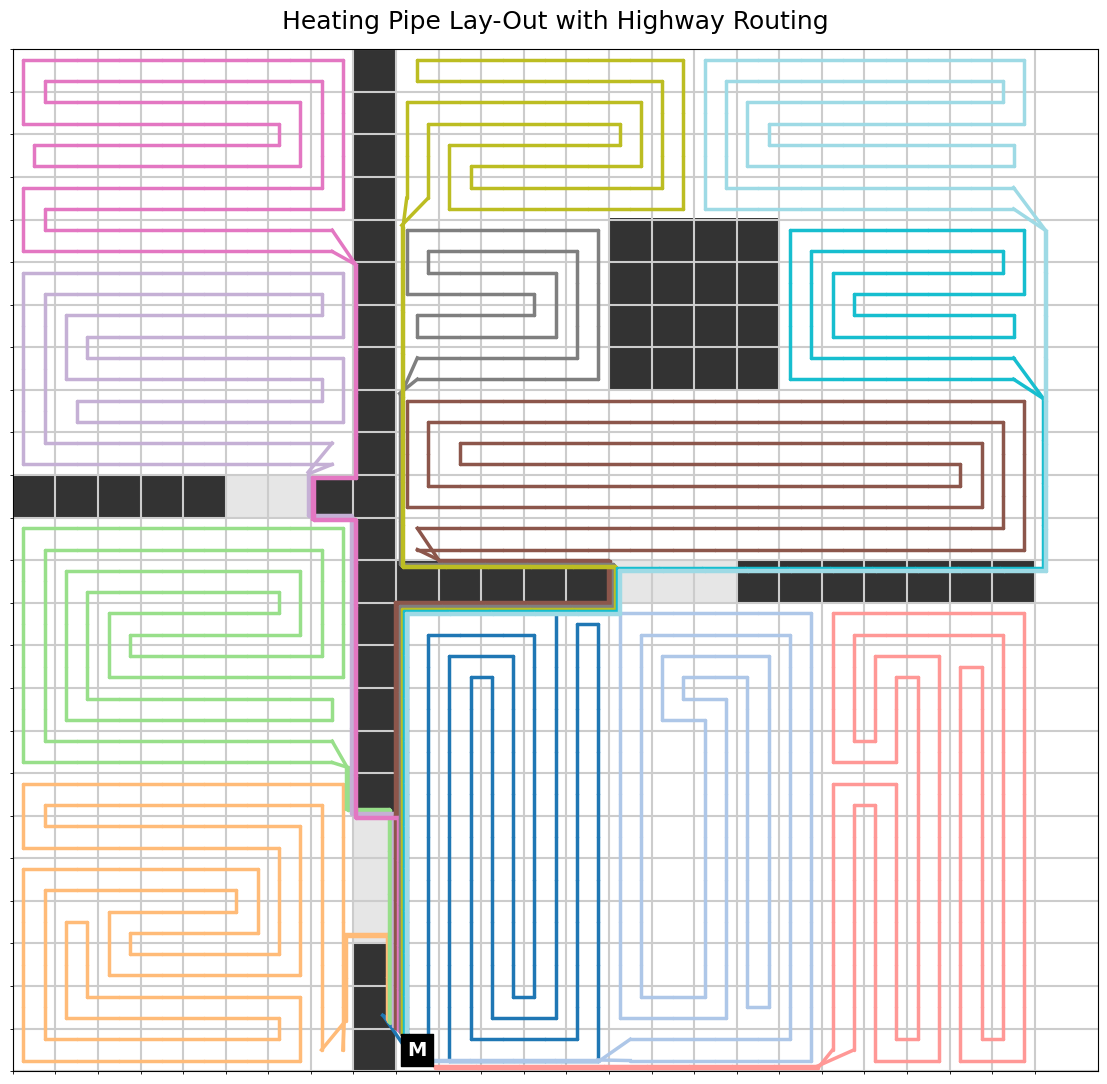

In [10]:
# ==========================================
# CELL 3: HEATING PIPE LAY OUT
# ==========================================


# EVOLUTION PARAMETERS 
POP_SIZE = 140
GENERATIONS = 500

# SCORE
COVERAGE_REWARD = 1000
TURNING_PENALTY = -500
CRASH_PENALTY = -2000
STRAIGHT_RUN_BONUS = 130   # Progressive bonus multiplied by distance traveled straight
COMPACT_TURN_REWARD = 400 #  bonus for tight  u-turns

# 1. THE SERPENTINE DECODER
def calculate_serpentine_fitness(dna_map, base_grid, zone_mask, start_pos):
    grid_size = base_grid.shape[0]
    visited = np.ones((grid_size, grid_size), dtype=bool) 
    visited[zone_mask] = False  
    visited[base_grid == -1] = True 
    visited[start_pos] = False 
    
    current_pos = start_pos
    visited[current_pos] = True
    path_x, path_y = [current_pos[1]], [current_pos[0]]
    
    score, mistakes, distance_since_last_turn = 1000.0, 0, 0 
    current_heading = None 
    previous_heading = None # Added to track U-turn geometry
    
    while True:
        r, c = current_pos
        valid_neighbors = []
        for heading, (dr, dc) in enumerate([(-1,0), (0,1), (1,0), (0,-1)]):
            nr, nc = r + dr, c + dc
            if 0 <= nr < grid_size and 0 <= nc < grid_size and not visited[nr, nc]:
                valid_neighbors.append(((nr, nc), heading))
                    
        if not valid_neighbors: break
            
        highest_priority = -1.0
        best_neighbor, best_heading = None, None
        for (nr, nc), heading in valid_neighbors:
            if dna_map[nr, nc] > highest_priority:
                highest_priority, best_neighbor, best_heading = dna_map[nr, nc], (nr, nc), heading

        if current_heading is not None:
            if best_heading == current_heading:
                distance_since_last_turn += 1
                
                # NEW: Progressive bonus for staying straight
                score += STRAIGHT_RUN_BONUS * distance_since_last_turn
                
                if distance_since_last_turn > 4 and mistakes > 0:
                    mistakes -= 1; distance_since_last_turn = 0
            else:
                if distance_since_last_turn < 2: score += TURNING_PENALTY 
                
                # NEW: Check for tight 1-tile U-turns
                if previous_heading is not None:
                    # If the cross-leg was exactly 1 tile long (dist == 0 upon turning)
                    # and the new heading is completely opposite to the previous heading
                    if distance_since_last_turn == 0 and abs(best_heading - previous_heading) == 2:
                        score += COMPACT_TURN_REWARD
                
                distance_since_last_turn = 0
                if abs(best_heading - current_heading) == 2:
                    score += CRASH_PENALTY; mistakes += 1
                    
                # Store the heading before we turned, to calculate the NEXT turn's geometry
                previous_heading = current_heading 
                
            if mistakes >= 3: break 

        current_heading = best_heading
        current_pos = best_neighbor
        visited[current_pos] = True
        path_x.append(current_pos[1]); path_y.append(current_pos[0])
        score += COVERAGE_REWARD 
        
    return int(score), path_x, path_y

def run_zoned_evolution(base_grid, zone_mask, start_pos):
    grid_size = base_grid.shape[0]
    population = [np.random.rand(grid_size, grid_size) for _ in range(POP_SIZE)]
    best_score, best_px, best_py = -9999, [], []
    
    for gen in range(GENERATIONS):
        scored = []
        for dna in population:
            s, px, py = calculate_serpentine_fitness(dna, base_grid, zone_mask, start_pos)
            scored.append((s, dna, px, py))
            
        scored.sort(key=lambda x: x[0], reverse=True)
        if scored[0][0] > best_score:
            best_score, best_px, best_py = scored[0][0], scored[0][2], scored[0][3]
            
        parents = [s[1] for s in scored[:20]]
        next_gen = parents[:5] 
        while len(next_gen) < POP_SIZE:
            p1, p2 = random.choice(parents), random.choice(parents)
            child = np.where(np.random.rand(grid_size, grid_size) > 0.5, p1, p2)
            child = np.where(np.random.rand(grid_size, grid_size) < 0.05, np.random.rand(grid_size, grid_size), child)
            next_gen.append(child)
        population = next_gen
    return best_score, best_px, best_py

# 2. PLUMBER ZONE GEOMETRY
def clean_path(px, py):
    cx, cy = [px[0]], [py[0]]
    for i in range(1, len(px)):
        if px[i] != cx[-1] or py[i] != cy[-1]:
            cx.append(px[i]); cy.append(py[i])
    return cx, cy

def get_simple_mitered_pipe(px, py, offset):
    n = len(px)
    sx, sy = np.zeros(n), np.zeros(n)
    for i in range(n):
        if i == 0: dx, dy = px[1]-px[0], py[1]-py[0]
        elif i == n-1: dx, dy = px[-1]-px[-2], py[-1]-py[-2]
        else: dx, dy = (px[i]-px[i-1] + px[i+1]-px[i]) / 2.0, (py[i]-py[i-1] + py[i+1]-py[i]) / 2.0
            
        l = np.hypot(dx, dy)
        if l == 0: nx, ny = 0, 0
        else:
            nx, ny = -dy/l, dx/l 
            if 0 < i < n-1:
                if (1/l) > 1.5: nx *= 1.5; ny *= 1.5
                else: nx *= (1/l); ny *= (1/l)
                    
        sx[i], sy[i] = px[i] + nx * offset, py[i] + ny * offset
    return sx, sy

# ==========================================
# EXECUTE & EDGE-BASED RENDER
# ==========================================
print("Plumber is routing pipes inside verified zones...")

for data in tqdm(engineering_manifest, desc="Zoned Evolution"):
    start_corner = data['start_corner']
    score, px, py = run_zoned_evolution(room_grid, data['mask'], start_corner)
    data['px'], data['py'] = clean_path(px, py) 

engineering_manifest.sort(key=lambda x: x['hw_dist'])

fig, ax = plt.subplots(figsize=(14, 14))
vis_grid = np.zeros_like(room_grid, dtype=float)
vis_grid[room_grid == 0] = 1.0   
vis_grid[room_grid == -1] = 0.2  
vis_grid[room_grid == -2] = 0.9  
ax.imshow(vis_grid, cmap='gray', vmin=0, vmax=1)

grid_size = room_grid.shape[0]
ax.set_xticks(np.arange(-0.5, grid_size, 1), minor=True)
ax.set_yticks(np.arange(-0.5, grid_size, 1), minor=True)
ax.grid(which="minor", color="#cccccc", linestyle='-', linewidth=1.5)
ax.set_xticks([]); ax.set_yticks([])

import matplotlib.cm as cm
zone_colors = cm.get_cmap('tab20', len(engineering_manifest)).colors

for i, data in enumerate(engineering_manifest):
    c_zone = zone_colors[i]
    
    # 1. RENDER HIGHWAYS (Pure Diagonal Translation from Cell 3 Manifest)
    hw_v_path = data.get('hw_v_path', [])
    if hw_v_path:
        lane_offset = (i - len(engineering_manifest)/2) * 0.05
        sup_offset = lane_offset - 0.015
        ret_offset = lane_offset + 0.015
        
        # Shift vertices from array index to plot coordinates (-0.5), then apply offset
        sx_h = [vc - 0.5 + sup_offset for vr, vc in hw_v_path]
        sy_h = [vr - 0.5 + sup_offset for vr, vc in hw_v_path]
        rx_h = [vc - 0.5 + ret_offset for vr, vc in hw_v_path]
        ry_h = [vr - 0.5 + ret_offset for vr, vc in hw_v_path]
        
        sh_segs = [[(sx_h[j], sy_h[j]), (sx_h[j+1], sy_h[j+1])] for j in range(len(sx_h)-1)]
        rh_segs = [[(rx_h[j], ry_h[j]), (rx_h[j+1], ry_h[j+1])] for j in range(len(rx_h)-1)]
        ax.add_collection(LineCollection(sh_segs, colors=c_zone, linewidths=2.5, capstyle='round'))
        ax.add_collection(LineCollection(rh_segs, colors=c_zone, linewidths=2.5, capstyle='round'))

    # 2. RENDER ZONE LOOPS 
    z_px, z_py = data['px'], data['py']
    if len(z_px) > 1:
        sx_z, sy_z = get_simple_mitered_pipe(z_px, z_py, 0.25)
        rx_z, ry_z = get_simple_mitered_pipe(z_px, z_py, -0.25)
        
        sz_segs = [[(sx_z[j], sy_z[j]), (sx_z[j+1], sy_z[j+1])] for j in range(len(sx_z)-1)]
        rz_segs = [[(rx_z[j], ry_z[j]), (rx_z[j+1], ry_z[j+1])] for j in range(len(rx_z)-1)]
        sz_segs.append([(sx_z[-1], sy_z[-1]), (rx_z[-1], ry_z[-1])]) 
        ax.add_collection(LineCollection(sz_segs, colors=c_zone, linewidths=2.5, capstyle='round'))
        ax.add_collection(LineCollection(rz_segs, colors=c_zone, linewidths=2.5, capstyle='round'))
    
    # 3. BRIDGE THE GAP
    if hw_v_path and len(z_px) > 1:
        ax.plot([sx_h[-1], sx_z[0]], [sy_h[-1], sy_z[0]], color=c_zone, linewidth=2.5)
        ax.plot([rx_h[-1], rx_z[0]], [ry_h[-1], ry_z[0]], color=c_zone, linewidth=2.5)

ax.scatter(MANIFOLD_POS[1], MANIFOLD_POS[0], color='black', s=500, marker='s', zorder=10)
ax.text(MANIFOLD_POS[1], MANIFOLD_POS[0], 'M', color='white', ha='center', va='center', fontweight='bold', fontsize=14, zorder=11)
ax.set_title("Heating Pipe Lay-Out with Highway Routing", fontsize=18, pad=15)
plt.show()